In [1]:
from data.loading_data import load_dataset, load_fraud_dataset, load_non_fraud_dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
dataset = load_dataset()
dataset_fraud = load_fraud_dataset()
dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
x_data = dataset.drop("Class", axis=1)
y_data = dataset["Class"]
x_data_fraud = dataset_fraud.drop("Class", axis=1)
y_data_fraud = dataset_fraud["Class"]

/var/folders/fp/dpzvj70s7vs2xby2sw6lv2j40000gn/T/ipykernel_10965/3301242449.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


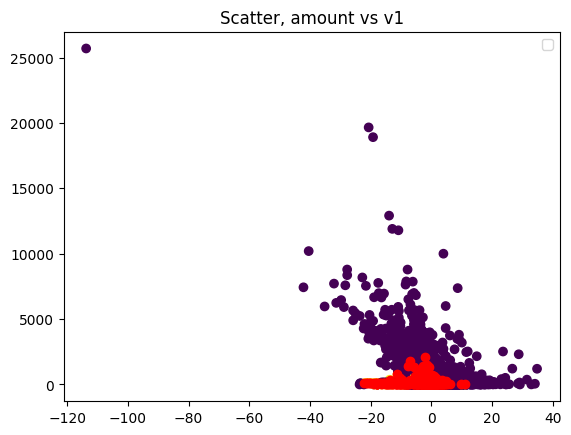

In [5]:
plt.scatter(x_data['V5'],x_data['Amount'],  c=y_data)
plt.scatter(x_data_fraud['V5'],x_data_fraud['Amount'],  c='red')
plt.legend()
plt.title("Scatter, amount vs v1")
plt.show()

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [7]:
pipeline_base = make_pipeline(RobustScaler())
preprocessor = make_column_transformer((pipeline_base, ['Amount', 'Time']), remainder='passthrough')
model = make_pipeline(preprocessor, LogisticRegression(class_weight="balanced", max_iter=2900))
model.named_steps
model.fit(x_train, y_train)


/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Amount', 'Time'])])),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=2900))])

In [8]:

model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('pipeline',
                                    Pipeline(steps=[('robustscaler',
                                                     RobustScaler())]),
                                    ['Amount', 'Time'])])),
  ('logisticregression',
   LogisticRegression(class_weight='balanced', max_iter=2900))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('pipeline',
                                  Pipeline(steps=[('robustscaler',
                                                   RobustScaler())]),
                                  ['Amount', 'Time'])]),
 'logisticregression': LogisticRegression(class_weight='balanced', max_iter=2900),
 'columntransformer__force_int_remainder_cols': True,
 'columntransformer__n_jobs': None,
 'columntransformer__remainder': 'passthro

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
param_grid = [
    {
        'logisticregression__penalty': ['l2'],
        'logisticregression__solver': ['lbfgs', 'sag'],
        'logisticregression__C': [0.01, 0.1, 1, 10]
    },
    {
        'logisticregression__penalty': ['l1'],
        'logisticregression__solver': ['liblinear', 'saga'],
        'logisticregression__C': [0.01, 0.1, 1, 10]
    },
    {
        'logisticregression__penalty': ['elasticnet'],
        'logisticregression__solver': ['saga'],
        'logisticregression__C': [0.01, 0.1, 1],
        'logisticregression__l1_ratio': [0.5, 0.7]
    }
]
grid = GridSearchCV(model, param_grid, cv=10, scoring='recall')
grid.fit(x_train, y_train)
grid.best_params_


KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
confusion_matrix(y_pred, y_test)

array([[56830,    43],
       [   34,    55]])

<Axes: >

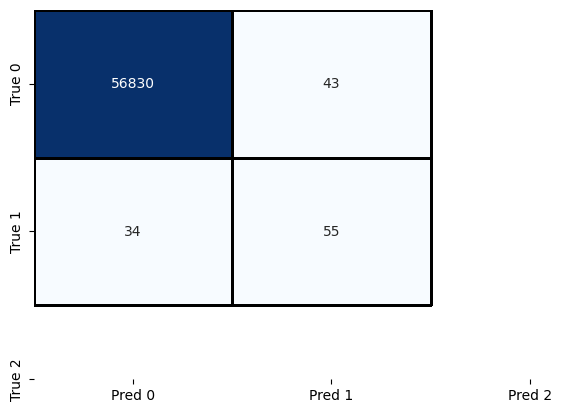

In [ ]:

sns.heatmap(confusion_matrix(y_pred, y_test),
                annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["True 0", "True 1", "True 2"],
    linewidths=1,
    linecolor="black")